# Diabetes Large - Benchmark Machine Learning và MLP NumPy

Notebook này huấn luyện và đối chuẩn 4 mô hình trên dataset `diabetes_prediction_dataset.csv`:

- **Logistic Regression**
- **Gaussian Naive Bayes**
- **Decision Tree**
- **MLP đa tầng thuần NumPy**: `input -> 64 -> 32 -> 16 -> 1`

Dataset bị mất cân bằng lớp khá rõ, vì vậy notebook không chỉ nhìn vào accuracy mà còn đánh giá bằng **Precision, Recall, F1, ROC-AUC, PR-AUC**, confusion matrix, thời gian huấn luyện và thời gian dự đoán.


## 1. Kiểm tra thư viện

Notebook không tự động cài package. Nếu cell này báo thiếu thư viện, hãy cài trong môi trường Python/Jupyter đang dùng rồi chạy lại notebook.


In [17]:
import importlib.util

required_modules = {
    "numpy": "numpy",
    "pandas": "pandas",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
}

missing = [pip_name for module_name, pip_name in required_modules.items()
           if importlib.util.find_spec(module_name) is None]

if missing:
    raise ModuleNotFoundError(
        "Notebook cần các package sau: " + ", ".join(missing) +
        ". Cài gợi ý: pip install numpy pandas scikit-learn matplotlib"
    )

import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

try:
    from IPython.display import display
except ImportError:
    display = print

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.precision", 4)
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Load Data

Cell này tìm dataset theo đường dẫn tương đối `../data/diabetes_prediction_dataset.csv` khi chạy notebook từ thư mục `notebook`. Một vài đường dẫn dự phòng được thêm để notebook vẫn chạy được nếu kernel đang đứng ở thư mục gốc project.


In [18]:
candidate_paths = [
    Path("../data/diabetes_prediction_dataset.csv"),
    Path("data/diabetes_prediction_dataset.csv"),
    Path("src/Assigment 03/diabetes_large/data/diabetes_prediction_dataset.csv"),
]

DATA_PATH = None
for candidate in candidate_paths:
    if candidate.exists():
        DATA_PATH = candidate.resolve()
        break

if DATA_PATH is None:
    searched = "\n".join(str(path) for path in candidate_paths)
    raise FileNotFoundError("Không tìm thấy dataset. Các đường dẫn đã thử:\n" + searched)

df = pd.read_csv(DATA_PATH)

print(f"Dataset path: {DATA_PATH}")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
display(df.head())


Dataset path: /Users/macos/Docs/Kì 1 năm 4/PTHTTM/src/Assigment 03/diabetes_large/data/diabetes_prediction_dataset.csv
Shape: 100,000 rows x 9 columns


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [19]:
# ============================================================
# FIGURE OUTPUT
# ============================================================

FIGURE_DIR = DATA_PATH.parent.parent / "report" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def save_current_figure(filename):
    output_path = FIGURE_DIR / filename
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved figure: {output_path}")
    return output_path


## 3. Kiểm tra dữ liệu ban đầu

Phần này kiểm tra kiểu dữ liệu, missing values, duplicate rows và phân phối target `diabetes`.


In [20]:
print("Data types:")
display(df.dtypes.to_frame("dtype"))

audit = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100,
    "unique_values": df.nunique(dropna=False),
})
print(f"Duplicate rows: {df.duplicated().sum():,}")
display(audit)

target_summary = df["diabetes"].value_counts().sort_index().to_frame("count")
target_summary["percent"] = target_summary["count"] / len(df) * 100
display(target_summary)

display(df.describe(include="all").T)


Data types:


,dtype
gender,str
age,float64
hypertension,int64
heart_disease,int64
smoking_history,str
bmi,float64
HbA1c_level,float64
blood_glucose_level,int64
diabetes,int64


Duplicate rows: 3,854


,missing_count,missing_percent,unique_values
gender,0,0.0,3
age,0,0.0,102
hypertension,0,0.0,2
heart_disease,0,0.0,2
smoking_history,0,0.0,6
bmi,0,0.0,4247
HbA1c_level,0,0.0,18
blood_glucose_level,0,0.0,18
diabetes,0,0.0,2


,count,percent
diabetes,,
0,91500,91.5
1,8500,8.5


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,100000,3,Female,58552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,100000.0,NaN,NaN,NaN,41.8859,22.5168,0.08,24.0,43.0,60.0,80.0
hypertension,100000.0,NaN,NaN,NaN,0.0748,0.2632,0.0,0.0,0.0,0.0,1.0
heart_disease,100000.0,NaN,NaN,NaN,0.0394,0.1946,0.0,0.0,0.0,0.0,1.0
smoking_history,100000,6,No Info,35816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,100000.0,NaN,NaN,NaN,27.3208,6.6368,10.01,23.63,27.32,29.58,95.69
HbA1c_level,100000.0,NaN,NaN,NaN,5.5275,1.0707,3.5,4.8,5.8,6.2,9.0
blood_glucose_level,100000.0,NaN,NaN,NaN,138.0581,40.7081,80.0,100.0,140.0,159.0,300.0
diabetes,100000.0,NaN,NaN,NaN,0.085,0.2789,0.0,0.0,0.0,0.0,1.0


## 4. EDA ngắn

Các biểu đồ dưới đây giúp nhìn nhanh mức mất cân bằng lớp và phân phối một số biến số quan trọng trước khi huấn luyện.


Saved figure: /Users/macos/Docs/Kì 1 năm 4/PTHTTM/src/Assigment 03/diabetes_large/report/figures/diabetes_large_eda_numeric_distributions.png


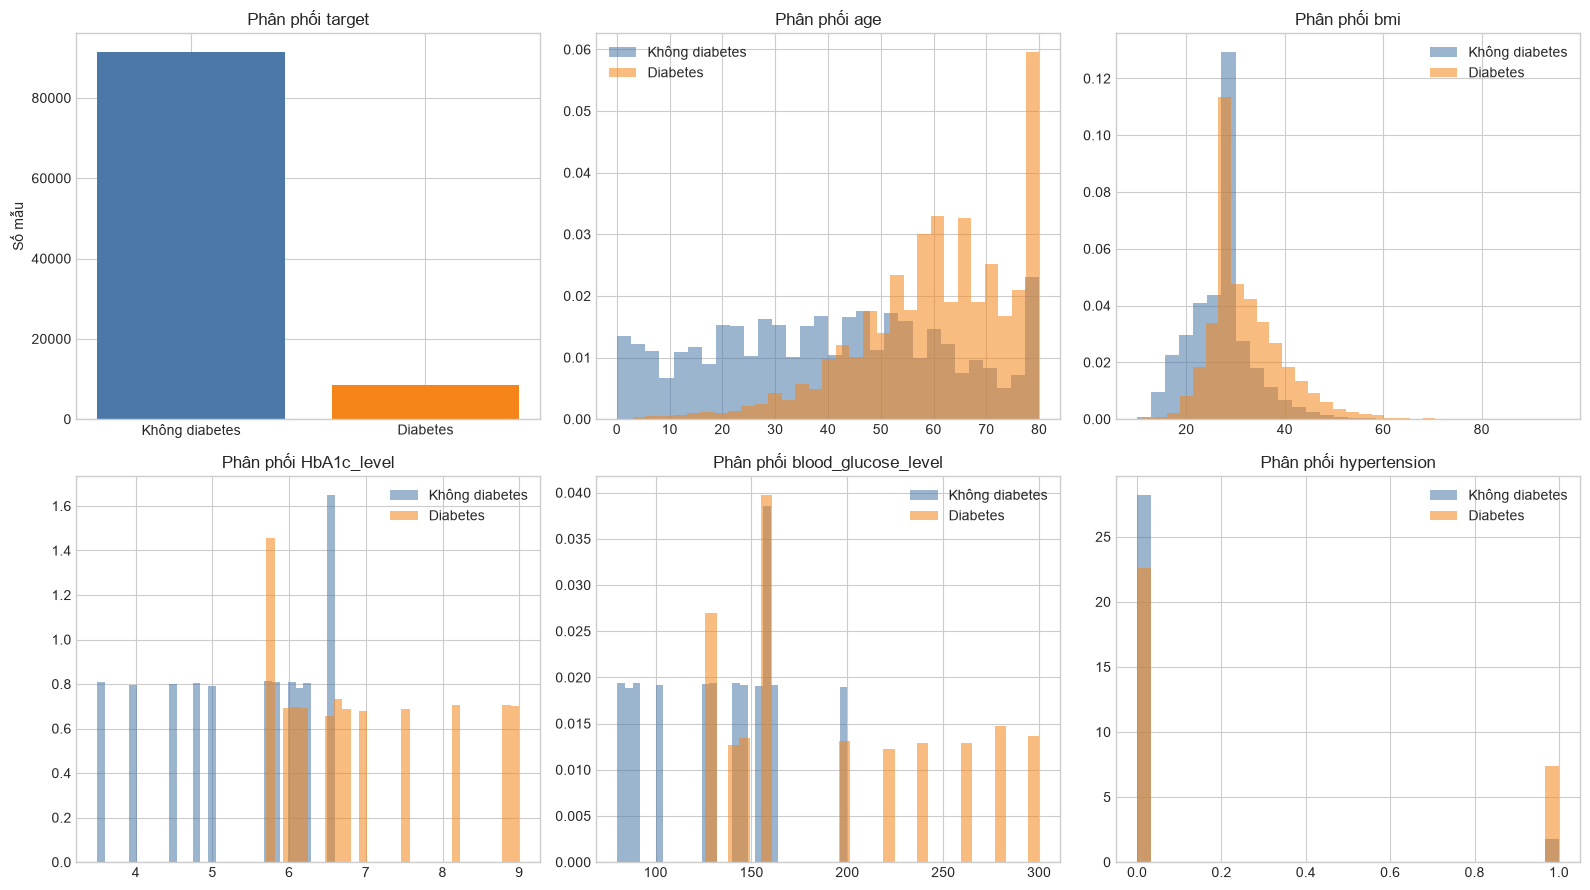

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

target_counts = df["diabetes"].value_counts().sort_index()
axes[0].bar(["Không diabetes", "Diabetes"], target_counts.values, color=["#4C78A8", "#F58518"])
axes[0].set_title("Phân phối target")
axes[0].set_ylabel("Số mẫu")

numeric_for_plot = ["age", "bmi", "HbA1c_level", "blood_glucose_level", "hypertension"]
for ax, col in zip(axes[1:], numeric_for_plot):
    for target_value, label, color in [(0, "Không diabetes", "#4C78A8"), (1, "Diabetes", "#F58518")]:
        ax.hist(
            df.loc[df["diabetes"] == target_value, col],
            bins=30,
            alpha=0.55,
            density=True,
            label=label,
            color=color,
        )
    ax.set_title(f"Phân phối {col}")
    ax.legend()

plt.tight_layout()
save_current_figure("diabetes_large_eda_numeric_distributions.png")
plt.show()


Saved figure: /Users/macos/Docs/Kì 1 năm 4/PTHTTM/src/Assigment 03/diabetes_large/report/figures/diabetes_large_eda_categorical_rates.png


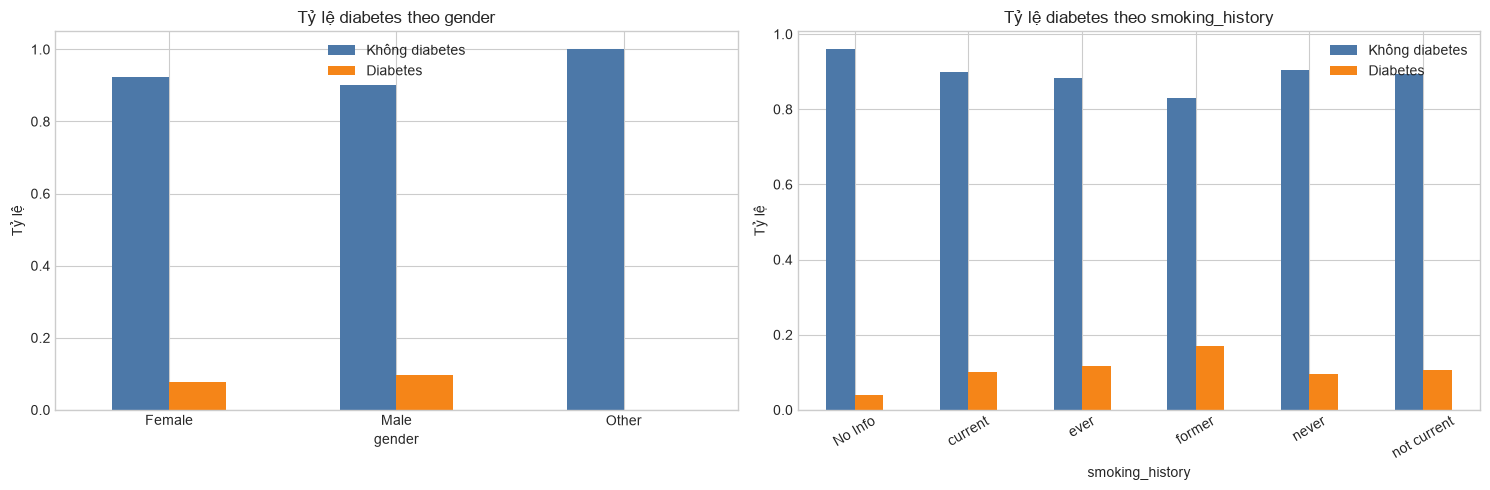

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

gender_rate = pd.crosstab(df["gender"], df["diabetes"], normalize="index")
gender_rate.plot(kind="bar", ax=axes[0], color=["#4C78A8", "#F58518"])
axes[0].set_title("Tỷ lệ diabetes theo gender")
axes[0].set_xlabel("gender")
axes[0].set_ylabel("Tỷ lệ")
axes[0].legend(["Không diabetes", "Diabetes"])
axes[0].tick_params(axis="x", rotation=0)

smoking_rate = pd.crosstab(df["smoking_history"], df["diabetes"], normalize="index")
smoking_rate.plot(kind="bar", ax=axes[1], color=["#4C78A8", "#F58518"])
axes[1].set_title("Tỷ lệ diabetes theo smoking_history")
axes[1].set_xlabel("smoking_history")
axes[1].set_ylabel("Tỷ lệ")
axes[1].legend(["Không diabetes", "Diabetes"])
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
save_current_figure("diabetes_large_eda_categorical_rates.png")
plt.show()


## 5. Train / Validation / Test Split

Dataset được chia theo tỷ lệ `70% train`, `15% validation`, `15% test`. Split dùng `stratify=y` để giữ tỷ lệ hai lớp gần giống nhau ở cả ba tập.


In [23]:
TARGET = "diabetes"
categorical_cols = ["gender", "smoking_history"]
numeric_cols = [col for col in df.columns if col not in categorical_cols + [TARGET]]

X_raw = df.drop(columns=[TARGET])
y = df[TARGET].astype(int).to_numpy()

X_train_val_raw, X_test_raw, y_train_val, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=y,
)

validation_size_inside_train_val = 0.15 / 0.85
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_train_val_raw,
    y_train_val,
    test_size=validation_size_inside_train_val,
    random_state=RANDOM_STATE,
    stratify=y_train_val,
)

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [len(y_train), len(y_val), len(y_test)],
    "positive_rate": [y_train.mean(), y_val.mean(), y_test.mean()],
})
display(split_summary)

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)


,split,rows,positive_rate
0,train,69999,0.085
1,validation,15001,0.085
2,test,15000,0.085


Numeric columns: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']
Categorical columns: ['gender', 'smoking_history']


## 6. Preprocessing tránh data leakage

`StandardScaler` và `OneHotEncoder` chỉ được fit trên training set. Validation/test chỉ dùng transform từ preprocessor đã fit.


In [24]:
try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", one_hot_encoder, categorical_cols),
    ],
    remainder="drop",
)

X_train = preprocessor.fit_transform(X_train_raw).astype(np.float64)
X_val = preprocessor.transform(X_val_raw).astype(np.float64)
X_test = preprocessor.transform(X_test_raw).astype(np.float64)

try:
    feature_names = preprocessor.get_feature_names_out()
except AttributeError:
    feature_names = np.array([f"feature_{idx}" for idx in range(X_train.shape[1])])

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("Số feature sau preprocessing:", len(feature_names))
display(pd.DataFrame(X_train[:5], columns=feature_names).head())


X_train: (69999, 15)
X_val: (15001, 15)
X_test: (15000, 15)
Số feature sau preprocessing: 15


,num__age,num__hypertension,num__heart_disease,num__bmi,num__HbA1c_level,num__blood_glucose_level,cat__gender_Female,cat__gender_Male,cat__gender_Other,cat__smoking_history_No Info,cat__smoking_history_current,cat__smoking_history_ever,cat__smoking_history_former,cat__smoking_history_never,cat__smoking_history_not current
0,-1.7266,-0.2825,-0.2036,-1.2557,0.4397,-1.4287,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,-0.3504,-0.2825,-0.2036,0.1506,-0.6802,-1.4287,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.4931,3.5396,-0.2036,1.8916,0.5331,3.9922,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-0.4836,-0.2825,-0.2036,0.0014,-1.8935,-1.1823,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.5724,-0.2825,-0.2036,2.5005,0.1597,0.4933,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## 7. Hàm đánh giá benchmark

Vì dataset mất cân bằng, threshold dự đoán được chọn trên validation set để tối ưu F1. Test set chỉ dùng cho đánh giá cuối cùng.


In [25]:
def safe_roc_auc(y_true, y_prob):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_prob)


def find_best_threshold(y_true, y_prob, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 181)

    best_threshold = 0.5
    best_f1 = -1.0
    for threshold in thresholds:
        y_pred = (y_prob >= threshold).astype(int)
        score = f1_score(y_true, y_pred, zero_division=0)
        if score > best_f1:
            best_f1 = score
            best_threshold = threshold
    return float(best_threshold), float(best_f1)


def evaluate_binary_model(name, y_true, y_prob, threshold, train_time, predict_time):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "Model": name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": safe_roc_auc(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob),
        "Train time (s)": train_time,
        "Predict time (s)": predict_time,
    }


def predict_positive_probability(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]

    scores = model.decision_function(X)
    return 1.0 / (1.0 + np.exp(-scores))


def display_results(results):
    results_df = pd.DataFrame(results).sort_values(["PR-AUC", "F1"], ascending=False).reset_index(drop=True)
    display(results_df.style.format({
        "Threshold": "{:.3f}",
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC-AUC": "{:.4f}",
        "PR-AUC": "{:.4f}",
        "Train time (s)": "{:.3f}",
        "Predict time (s)": "{:.3f}",
    }))
    return results_df


## 8. Huấn luyện 3 mô hình Machine Learning cơ bản

Ba mô hình này dùng cùng một dữ liệu đã preprocess để benchmark công bằng với MLP NumPy.


In [26]:
baseline_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Gaussian Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=50,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
}

benchmark_results = []
test_predictions = {}
validation_predictions = {}

for model_name, model in baseline_models.items():
    print(f"Training {model_name}...")

    start = time.perf_counter()
    model.fit(X_train, y_train)
    train_time = time.perf_counter() - start

    val_prob = predict_positive_probability(model, X_val)
    best_threshold, best_val_f1 = find_best_threshold(y_val, val_prob)

    start = time.perf_counter()
    test_prob = predict_positive_probability(model, X_test)
    predict_time = time.perf_counter() - start

    result = evaluate_binary_model(
        model_name,
        y_test,
        test_prob,
        best_threshold,
        train_time,
        predict_time,
    )
    benchmark_results.append(result)
    validation_predictions[model_name] = val_prob
    test_predictions[model_name] = {
        "probability": test_prob,
        "prediction": (test_prob >= best_threshold).astype(int),
        "threshold": best_threshold,
    }

    print(f"  Best validation F1: {best_val_f1:.4f} tại threshold={best_threshold:.3f}")
    print(f"  Test F1: {result['F1']:.4f}, PR-AUC: {result['PR-AUC']:.4f}")

baseline_results_df = display_results(benchmark_results)


Training Logistic Regression...
  Best validation F1: 0.7311 tại threshold=0.875
  Test F1: 0.7300, PR-AUC: 0.8209
Training Gaussian Naive Bayes...
  Best validation F1: 0.4673 tại threshold=0.950
  Test F1: 0.4507, PR-AUC: 0.5043
Training Decision Tree...
  Best validation F1: 0.8140 tại threshold=0.890
  Test F1: 0.8039, PR-AUC: 0.8514


,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Train time (s),Predict time (s)
0,Decision Tree,0.890,0.9721,1.0000,0.6722,0.8039,0.9731,0.8514,0.063,0.000
1,Logistic Regression,0.875,0.9573,0.7900,0.6784,0.7300,0.9629,0.8209,0.034,0.000
2,Gaussian Naive Bayes,0.950,0.8265,0.3083,0.8376,0.4507,0.9093,0.5043,0.009,0.003


## 9. MLP đa tầng thuần NumPy

MLP dưới đây không dùng TensorFlow, PyTorch, Keras hay `sklearn.neural_network`. Mạng có kiến trúc `input -> 64 -> 32 -> 16 -> 1`, dùng ReLU ở hidden layers và sigmoid ở output layer.

Các cải tiến chính:

- Mini-batch gradient descent
- Class weighting để xử lý mất cân bằng lớp
- L2 regularization
- Theo dõi validation loss, F1, ROC-AUC, PR-AUC
- Early stopping theo validation PR-AUC


In [27]:
class NumpyMLPClassifier:
    def __init__(
        self,
        hidden_layers=(64, 32, 16),
        learning_rate=0.01,
        epochs=80,
        batch_size=1024,
        l2=1e-4,
        patience=10,
        min_delta=1e-4,
        random_state=42,
        verbose=True,
    ):
        self.hidden_layers = hidden_layers
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.l2 = l2
        self.patience = patience
        self.min_delta = min_delta
        self.random_state = random_state
        self.verbose = verbose

    def _initialize_parameters(self, input_dim):
        rng = np.random.default_rng(self.random_state)
        layer_sizes = [input_dim, *self.hidden_layers, 1]
        self.weights = []
        self.biases = []

        for fan_in, fan_out in zip(layer_sizes[:-1], layer_sizes[1:]):
            if fan_out == 1:
                limit = np.sqrt(6.0 / (fan_in + fan_out))
                weight = rng.uniform(-limit, limit, size=(fan_in, fan_out))
            else:
                weight = rng.normal(0.0, np.sqrt(2.0 / fan_in), size=(fan_in, fan_out))
            bias = np.zeros((1, fan_out))

            self.weights.append(weight.astype(np.float64))
            self.biases.append(bias.astype(np.float64))

    @staticmethod
    def _relu(x):
        return np.maximum(0.0, x)

    @staticmethod
    def _sigmoid(x):
        x = np.clip(x, -500, 500)
        return 1.0 / (1.0 + np.exp(-x))

    def _forward(self, X):
        activations = [X]
        z_values = []
        current = X

        for weight, bias in zip(self.weights[:-1], self.biases[:-1]):
            z = current @ weight + bias
            current = self._relu(z)
            z_values.append(z)
            activations.append(current)

        output_z = current @ self.weights[-1] + self.biases[-1]
        output = self._sigmoid(output_z)
        z_values.append(output_z)
        activations.append(output)

        return output, {"activations": activations, "z_values": z_values}

    def _set_class_weights(self, y):
        positives = np.sum(y == 1)
        negatives = np.sum(y == 0)
        total = len(y)

        if positives == 0 or negatives == 0:
            self.class_weight_ = {0: 1.0, 1: 1.0}
        else:
            self.class_weight_ = {
                0: total / (2.0 * negatives),
                1: total / (2.0 * positives),
            }

    def _weighted_binary_cross_entropy(self, y_true, y_prob):
        y_true = y_true.reshape(-1, 1)
        y_prob = np.clip(y_prob, 1e-8, 1 - 1e-8)
        sample_weights = np.where(y_true == 1, self.class_weight_[1], self.class_weight_[0])

        data_loss = -np.mean(
            sample_weights * (
                y_true * np.log(y_prob) + (1.0 - y_true) * np.log(1.0 - y_prob)
            )
        )
        regularization = self.l2 / (2.0 * len(y_true)) * sum(np.sum(weight ** 2) for weight in self.weights)
        return float(data_loss + regularization)

    def _backward(self, y_batch, cache):
        y_batch = y_batch.reshape(-1, 1)
        batch_size = len(y_batch)
        activations = cache["activations"]
        z_values = cache["z_values"]

        sample_weights = np.where(y_batch == 1, self.class_weight_[1], self.class_weight_[0])
        d_z = sample_weights * (activations[-1] - y_batch) / batch_size

        grad_weights = [None] * len(self.weights)
        grad_biases = [None] * len(self.biases)

        for layer_idx in reversed(range(len(self.weights))):
            previous_activation = activations[layer_idx]
            grad_weights[layer_idx] = previous_activation.T @ d_z + (self.l2 / batch_size) * self.weights[layer_idx]
            grad_biases[layer_idx] = np.sum(d_z, axis=0, keepdims=True)

            if layer_idx > 0:
                d_activation = d_z @ self.weights[layer_idx].T
                d_z = d_activation * (z_values[layer_idx - 1] > 0)

        return grad_weights, grad_biases

    def _copy_parameters(self):
        return {
            "weights": [weight.copy() for weight in self.weights],
            "biases": [bias.copy() for bias in self.biases],
        }

    def _restore_parameters(self, parameters):
        self.weights = [weight.copy() for weight in parameters["weights"]]
        self.biases = [bias.copy() for bias in parameters["biases"]]

    def fit(self, X_train, y_train, X_val, y_val):
        y_train = y_train.astype(np.float64)
        y_val = y_val.astype(np.float64)

        self._initialize_parameters(input_dim=X_train.shape[1])
        self._set_class_weights(y_train)

        rng = np.random.default_rng(self.random_state)
        self.history_ = []
        best_score = -np.inf
        best_parameters = self._copy_parameters()
        best_epoch = 0
        epochs_without_improvement = 0

        for epoch in range(1, self.epochs + 1):
            shuffled_indices = rng.permutation(len(X_train))

            for start in range(0, len(X_train), self.batch_size):
                batch_indices = shuffled_indices[start:start + self.batch_size]
                X_batch = X_train[batch_indices]
                y_batch = y_train[batch_indices]

                _, cache = self._forward(X_batch)
                grad_weights, grad_biases = self._backward(y_batch, cache)

                for layer_idx in range(len(self.weights)):
                    self.weights[layer_idx] -= self.learning_rate * grad_weights[layer_idx]
                    self.biases[layer_idx] -= self.learning_rate * grad_biases[layer_idx]

            train_prob = self.predict_proba(X_train)
            val_prob = self.predict_proba(X_val)
            val_threshold, val_f1 = find_best_threshold(y_val, val_prob)
            val_pr_auc = average_precision_score(y_val, val_prob)

            epoch_record = {
                "epoch": epoch,
                "train_loss": self._weighted_binary_cross_entropy(y_train, train_prob.reshape(-1, 1)),
                "val_loss": self._weighted_binary_cross_entropy(y_val, val_prob.reshape(-1, 1)),
                "val_threshold": val_threshold,
                "val_f1": val_f1,
                "val_roc_auc": safe_roc_auc(y_val, val_prob),
                "val_pr_auc": val_pr_auc,
            }
            self.history_.append(epoch_record)

            if self.verbose and (epoch == 1 or epoch % 5 == 0):
                print(
                    f"Epoch {epoch:03d} | "
                    f"train_loss={epoch_record['train_loss']:.4f} | "
                    f"val_loss={epoch_record['val_loss']:.4f} | "
                    f"val_f1={val_f1:.4f} | "
                    f"val_pr_auc={val_pr_auc:.4f}"
                )

            if val_pr_auc > best_score + self.min_delta:
                best_score = val_pr_auc
                best_parameters = self._copy_parameters()
                best_epoch = epoch
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= self.patience:
                if self.verbose:
                    print(f"Early stopping tại epoch {epoch}. Best epoch: {best_epoch}")
                break

        self._restore_parameters(best_parameters)
        self.best_epoch_ = best_epoch
        self.best_validation_pr_auc_ = best_score
        return self

    def predict_proba(self, X):
        probability, _ = self._forward(X)
        return probability.ravel()


## 10. Huấn luyện MLP NumPy

Cell này có thể chạy lâu hơn các mô hình ML cơ bản vì toàn bộ forward/backpropagation được viết bằng NumPy thuần.


In [28]:
mlp = NumpyMLPClassifier(
    hidden_layers=(64, 32, 16),
    learning_rate=0.01,
    epochs=80,
    batch_size=1024,
    l2=1e-4,
    patience=10,
    min_delta=1e-4,
    random_state=RANDOM_STATE,
    verbose=True,
)

start = time.perf_counter()
mlp.fit(X_train, y_train, X_val, y_val)
mlp_train_time = time.perf_counter() - start

mlp_val_prob = mlp.predict_proba(X_val)
mlp_threshold, mlp_val_f1 = find_best_threshold(y_val, mlp_val_prob)

start = time.perf_counter()
mlp_test_prob = mlp.predict_proba(X_test)
mlp_predict_time = time.perf_counter() - start

mlp_result = evaluate_binary_model(
    "NumPy MLP (64-32-16)",
    y_test,
    mlp_test_prob,
    mlp_threshold,
    mlp_train_time,
    mlp_predict_time,
)

benchmark_results.append(mlp_result)
validation_predictions["NumPy MLP (64-32-16)"] = mlp_val_prob
test_predictions["NumPy MLP (64-32-16)"] = {
    "probability": mlp_test_prob,
    "prediction": (mlp_test_prob >= mlp_threshold).astype(int),
    "threshold": mlp_threshold,
}

print(f"Best epoch: {mlp.best_epoch_}")
print(f"Best validation PR-AUC: {mlp.best_validation_pr_auc_:.4f}")
print(f"Best validation F1: {mlp_val_f1:.4f} tại threshold={mlp_threshold:.3f}")
print(f"Test F1: {mlp_result['F1']:.4f}, PR-AUC: {mlp_result['PR-AUC']:.4f}")


Epoch 001 | train_loss=0.4545 | val_loss=0.4528 | val_f1=0.5466 | val_pr_auc=0.5497
Epoch 005 | train_loss=0.2812 | val_loss=0.2779 | val_f1=0.6764 | val_pr_auc=0.7671
Epoch 010 | train_loss=0.2614 | val_loss=0.2585 | val_f1=0.6977 | val_pr_auc=0.7901
Epoch 015 | train_loss=0.2558 | val_loss=0.2527 | val_f1=0.7073 | val_pr_auc=0.7994
Epoch 020 | train_loss=0.2524 | val_loss=0.2503 | val_f1=0.7115 | val_pr_auc=0.8027
Epoch 025 | train_loss=0.2502 | val_loss=0.2477 | val_f1=0.7162 | val_pr_auc=0.8083
Epoch 030 | train_loss=0.2480 | val_loss=0.2463 | val_f1=0.7210 | val_pr_auc=0.8101
Epoch 035 | train_loss=0.2465 | val_loss=0.2453 | val_f1=0.7233 | val_pr_auc=0.8117
Epoch 040 | train_loss=0.2448 | val_loss=0.2437 | val_f1=0.7273 | val_pr_auc=0.8144
Epoch 045 | train_loss=0.2433 | val_loss=0.2422 | val_f1=0.7282 | val_pr_auc=0.8166
Epoch 050 | train_loss=0.2425 | val_loss=0.2420 | val_f1=0.7307 | val_pr_auc=0.8165
Epoch 055 | train_loss=0.2409 | val_loss=0.2402 | val_f1=0.7315 | val_pr_auc

## 11. Learning curve của MLP

Biểu đồ giúp kiểm tra MLP có học ổn định không và early stopping dừng ở giai đoạn nào.


,epoch,train_loss,val_loss,val_threshold,val_f1,val_roc_auc,val_pr_auc
75,76,0.2365,0.2363,0.850,0.7359,0.9655,0.8237
76,77,0.2364,0.2362,0.845,0.7362,0.9655,0.8239
77,78,0.2361,0.2361,0.875,0.7368,0.9655,0.8234
78,79,0.2359,0.2358,0.850,0.7362,0.9656,0.8241
79,80,0.2359,0.2357,0.845,0.7367,0.9656,0.8246


Saved figure: /Users/macos/Docs/Kì 1 năm 4/PTHTTM/src/Assigment 03/diabetes_large/report/figures/diabetes_large_mlp_learning_curve.png


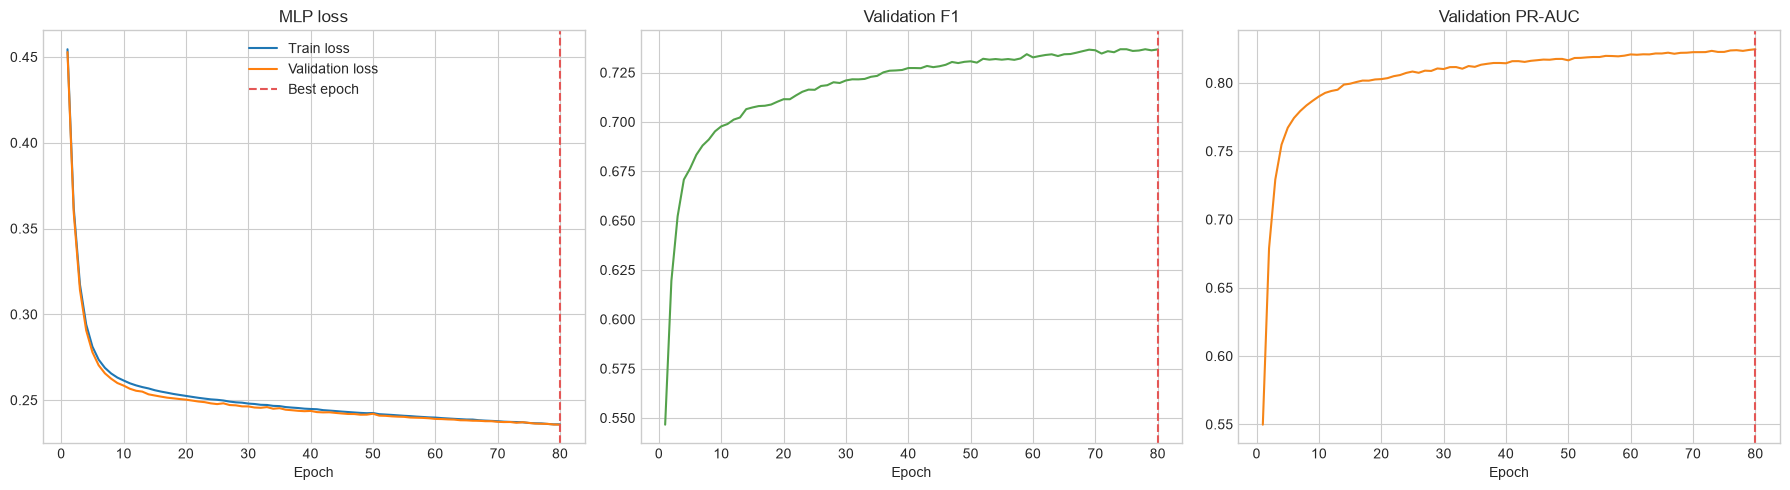

In [29]:
history_df = pd.DataFrame(mlp.history_)
display(history_df.tail())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Validation loss")
axes[0].axvline(mlp.best_epoch_, color="#E45756", linestyle="--", label="Best epoch")
axes[0].set_title("MLP loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["val_f1"], color="#54A24B")
axes[1].axvline(mlp.best_epoch_, color="#E45756", linestyle="--")
axes[1].set_title("Validation F1")
axes[1].set_xlabel("Epoch")

axes[2].plot(history_df["epoch"], history_df["val_pr_auc"], color="#F58518")
axes[2].axvline(mlp.best_epoch_, color="#E45756", linestyle="--")
axes[2].set_title("Validation PR-AUC")
axes[2].set_xlabel("Epoch")

plt.tight_layout()
save_current_figure("diabetes_large_mlp_learning_curve.png")
plt.show()


## 12. Benchmark toàn diện 4 mô hình

Bảng dưới đây là kết quả trên test set. Các threshold được chọn bằng validation set, không chọn trực tiếp trên test set.


In [30]:
results_df = display_results(benchmark_results)
results_df


,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Train time (s),Predict time (s)
0,Decision Tree,0.890,0.9721,1.0000,0.6722,0.8039,0.9731,0.8514,0.063,0.000
1,NumPy MLP (64-32-16),0.845,0.9559,0.7593,0.7051,0.7312,0.9658,0.8265,17.237,0.003
2,Logistic Regression,0.875,0.9573,0.7900,0.6784,0.7300,0.9629,0.8209,0.034,0.000
3,Gaussian Naive Bayes,0.950,0.8265,0.3083,0.8376,0.4507,0.9093,0.5043,0.009,0.003


,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Train time (s),Predict time (s)
0,Decision Tree,0.890,0.9721,1.0000,0.6722,0.8039,0.9731,0.8514,0.0635,0.0004
1,NumPy MLP (64-32-16),0.845,0.9559,0.7593,0.7051,0.7312,0.9658,0.8265,17.2372,0.0033
2,Logistic Regression,0.875,0.9573,0.7900,0.6784,0.7300,0.9629,0.8209,0.0341,0.0003
3,Gaussian Naive Bayes,0.950,0.8265,0.3083,0.8376,0.4507,0.9093,0.5043,0.0087,0.0032


Saved figure: /Users/macos/Docs/Kì 1 năm 4/PTHTTM/src/Assigment 03/diabetes_large/report/figures/diabetes_large_metric_comparison.png


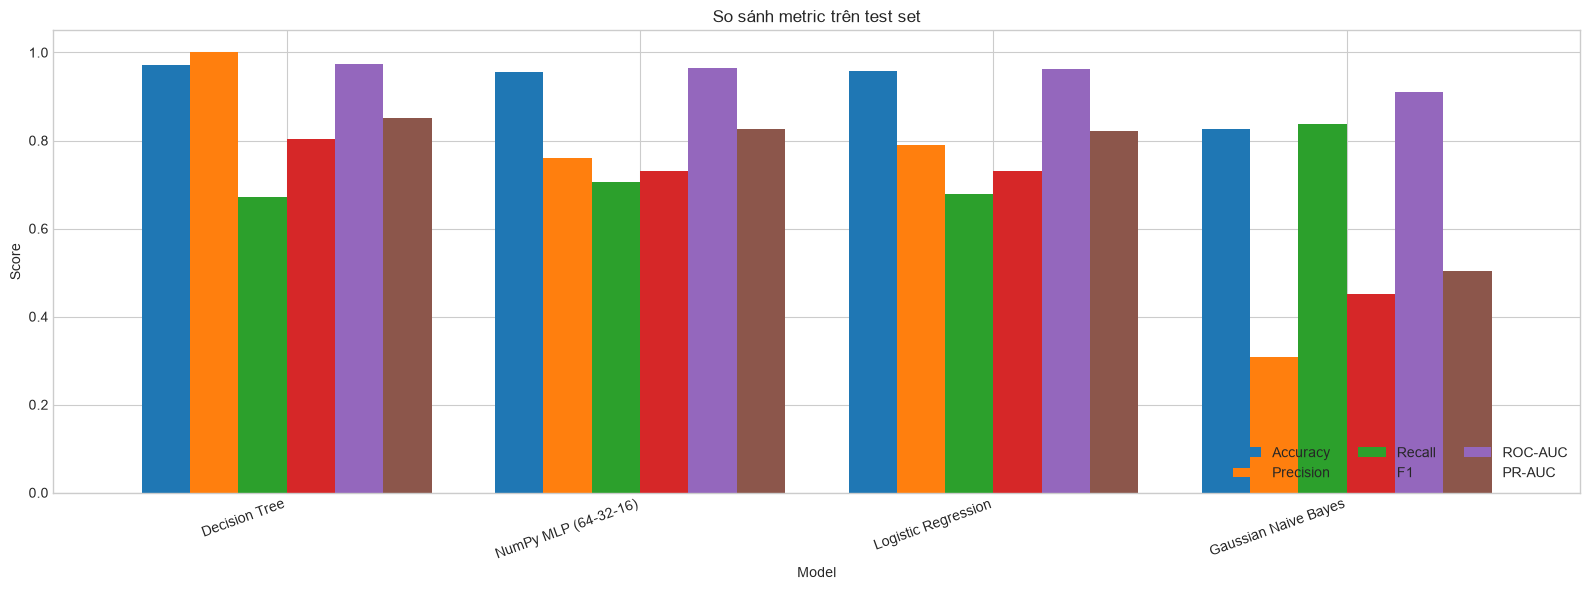

In [31]:
metric_cols = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]

plot_df = results_df.set_index("Model")[metric_cols]
ax = plot_df.plot(kind="bar", figsize=(16, 6), width=0.82)
ax.set_title("So sánh metric trên test set")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right", ncol=3)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
save_current_figure("diabetes_large_metric_comparison.png")
plt.show()


## 13. Confusion Matrix

Confusion matrix cho thấy từng mô hình đang đánh đổi false positive và false negative như thế nào.


Saved figure: /Users/macos/Docs/Kì 1 năm 4/PTHTTM/src/Assigment 03/diabetes_large/report/figures/diabetes_large_confusion_matrices.png


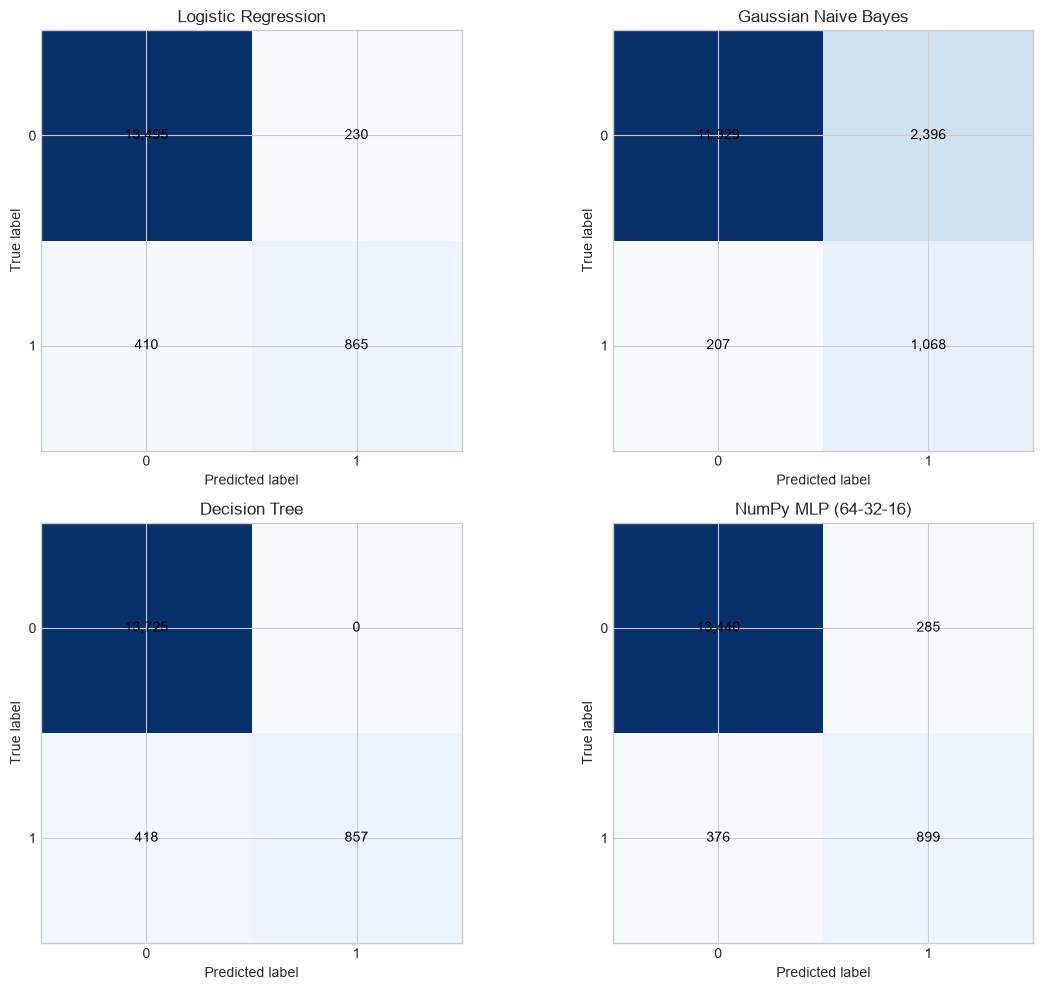

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, (model_name, prediction_info) in zip(axes, test_predictions.items()):
    matrix = confusion_matrix(y_test, prediction_info["prediction"])
    image = ax.imshow(matrix, cmap="Blues")
    ax.set_title(model_name)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["0", "1"])
    ax.set_yticklabels(["0", "1"])

    for row in range(matrix.shape[0]):
        for col in range(matrix.shape[1]):
            ax.text(col, row, f"{matrix[row, col]:,}", ha="center", va="center", color="black")

plt.tight_layout()
save_current_figure("diabetes_large_confusion_matrices.png")
plt.show()


## 14. Kết luận

Với bài toán có class imbalance, accuracy thường dễ gây hiểu nhầm vì class `0` chiếm đa số. Vì vậy phần kết luận ưu tiên **PR-AUC** và **F1** để chọn mô hình cân bằng hơn giữa precision và recall.


In [33]:
best_by_pr_auc = results_df.sort_values("PR-AUC", ascending=False).iloc[0]
best_by_f1 = results_df.sort_values("F1", ascending=False).iloc[0]

print("Kết luận benchmark:")
print(f"- Mô hình tốt nhất theo PR-AUC: {best_by_pr_auc['Model']} ({best_by_pr_auc['PR-AUC']:.4f})")
print(f"- Mô hình tốt nhất theo F1: {best_by_f1['Model']} ({best_by_f1['F1']:.4f})")
print("- Accuracy vẫn được báo cáo, nhưng không nên dùng một mình do dataset mất cân bằng.")

display(results_df[[
    "Model", "Threshold", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC",
    "Train time (s)", "Predict time (s)"
]])


Kết luận benchmark:
- Mô hình tốt nhất theo PR-AUC: Decision Tree (0.8514)
- Mô hình tốt nhất theo F1: Decision Tree (0.8039)
- Accuracy vẫn được báo cáo, nhưng không nên dùng một mình do dataset mất cân bằng.


,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Train time (s),Predict time (s)
0,Decision Tree,0.890,0.9721,1.0000,0.6722,0.8039,0.9731,0.8514,0.0635,0.0004
1,NumPy MLP (64-32-16),0.845,0.9559,0.7593,0.7051,0.7312,0.9658,0.8265,17.2372,0.0033
2,Logistic Regression,0.875,0.9573,0.7900,0.6784,0.7300,0.9629,0.8209,0.0341,0.0003
3,Gaussian Naive Bayes,0.950,0.8265,0.3083,0.8376,0.4507,0.9093,0.5043,0.0087,0.0032
